# 5.0 Data Processing V2 (2D Cost-Level × Transition Classification)

## Objectives
1.  **Data Ingestion & Mapping**: Robust ICD-9/ICD-10 mapping for condition flags across MEPS Panels 18-23 (2013-2019).
2.  **Feature Engineering**: Inflation adjustment, medication features, utilization ratios, care phenotype clustering.
3.  **2D Target Definition**: 10-class patient classification combining Y1 cost level (Low/Mid/High) with cost transition direction (Improve/Stable/Escalate), with an extra Low_Jumper split.

## Key Design Decision: 2D Classification
A 1D classification using only transition direction groups patients with vastly different cost levels (e.g., Low→Low at $100 and Extreme→Extreme at $50K are both "Stable"). This causes Stage 2 models to struggle with enormous within-group variance.

The 2D approach crosses **Y1 cost level** (3 tiers) with **transition direction**, producing 10 classes where patients share both similar starting costs and similar trajectories. The Low category gets an extra split (MildRise vs Jumper) because low-cost escalators span a wide range.


## Data Requirements

Use panels/files that include both `TOTEXPY1` and `TOTEXPY2` for each person-year. Panels missing either field are skipped during processing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# --- CONFIGURATION ---
# Use newly parsed data in data/processed_v2 (has Panels 18-21 complete with TOTEXPY1/Y2)
DATA_DIR = Path('../data/processed_v2')
# Fallback to archive for files not yet re-parsed
DATA_DIR_ARCHIVE = Path('../archive_v1/data/processed')
DATA_DIR_NEW = DATA_DIR  # Alias for compatibility
OUTPUT_DIR = Path('../data/processed_v2')
REPORT_DIR = Path('../reports')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
(REPORT_DIR / 'figures').mkdir(exist_ok=True)
(REPORT_DIR / 'tables').mkdir(exist_ok=True)

# Medical CPI Factors (Base 2025)
CPI_FACTORS = {
    2013: 1.45, 2014: 1.41, 2015: 1.37,
    2016: 1.32, 2017: 1.28, 2018: 1.24,
    2019: 1.20, 2020: 1.18
}

# Panel Mapping - IMPORTANT: Panels 22+ have different data structure
# Panels 18-21: Longitudinal files contain BOTH Y1 and Y2 expense data (TOTEXPY1, TOTEXPY2)
# Panels 22+: Longitudinal files only have Y2 data, need Full Year Consolidated for Y1
#
# To use Panel 22: Download HC-201 (2017 Full Year), save as h201.parquet
# To use Panel 23: Download HC-216 (2018 Full Year), save as h216.parquet
#
PANEL_MAP = [
    # All panels now have complete TOTEXPY1 and TOTEXPY2 data
    {'panel': 18, 'long': 'h172', 'cond_y1': 'h162', 'meds_y1': 'h160a', 'year1': 2013, 'naming': 'Y1Y2'},
    {'panel': 19, 'long': 'h183', 'cond_y1': 'h170', 'meds_y1': 'h168a', 'year1': 2014, 'naming': 'Y1Y2'},
    {'panel': 20, 'long': 'h193', 'cond_y1': 'h180', 'meds_y1': 'h178a', 'year1': 2015, 'naming': 'Y1Y2'},
    {'panel': 21, 'long': 'h202', 'cond_y1': 'h190', 'meds_y1': 'h188a', 'year1': 2016, 'naming': 'Y1Y2'},
    {'panel': 22, 'long': 'h210', 'cond_y1': 'h199', 'meds_y1': 'h206a', 'year1': 2017, 'naming': 'Y1Y2'},
    {'panel': 23, 'long': 'h217', 'cond_y1': 'h207', 'meds_y1': 'h206a', 'year1': 2018, 'naming': 'Y1Y2'},
]

ILL_DEFINED_CCS_ICD9 = [str(i) for i in range(245, 260)]

print(f"Setup Complete. Reading from {DATA_DIR}")
print(f"Panels: {[p['panel'] for p in PANEL_MAP]}")

Setup Complete. Reading from ../data/processed_v2
Panels: [18, 19, 20, 21, 22, 23]


In [2]:
def process_panel(pmap):
    """
    Process a single MEPS panel: Load longitudinal data and merge with Conditions/Meds.
    Handles both old (Y1/Y2) and new (year suffix) naming conventions.
    """
    panel = pmap['panel']
    year1 = pmap['year1']
    year2 = year1 + 1
    naming = pmap.get('naming', 'Y1Y2')
    
    print(f"Processing Panel {panel} ({year1}-{year2})...", end=" ")
    
    # 1. Load Longitudinal File (check both directories)
    f_long = DATA_DIR / f"{pmap['long']}.parquet"
    if not f_long.exists():
        f_long = DATA_DIR_ARCHIVE / f"{pmap['long']}.parquet"
    if not f_long.exists():
        print(f"SKIP - {pmap['long']}.parquet not found")
        return None
    df_long = pd.read_parquet(f_long)
    
    # 2. For Panels 22+, check if we need Full Year file for Y1 data
    if naming == 'YEAR' and 'fullyear_y1' in pmap:
        # Check both DATA_DIR and DATA_DIR_NEW for the full year file
        f_fy = DATA_DIR / f"{pmap['fullyear_y1']}.parquet"
        if not f_fy.exists():
            f_fy = DATA_DIR_NEW / f"{pmap['fullyear_y1']}.parquet"
        
        if f_fy.exists():
            print(f"(merging with {pmap['fullyear_y1']} for Y1)...", end=" ")
            df_fy = pd.read_parquet(f_fy)
            # Merge Y1 expense data from Full Year file
            y1_cols = [c for c in df_fy.columns if 'DUPERSID' in c or f'TOTEXP' in c or 'TOTSLF' in c]
            if y1_cols:
                df_long = df_long.merge(df_fy[['DUPERSID'] + [c for c in y1_cols if c != 'DUPERSID']], 
                                        on='DUPERSID', how='left', suffixes=('', '_FY'))
        else:
            # Check if longitudinal file has required Y1 expense columns
            y1_exp_cols = [c for c in df_long.columns if 'TOTEXP' in c and str(year1)[-2:] in c]
            if not y1_exp_cols and 'TOTEXPY1' not in df_long.columns:
                print(f"SKIP - No Y1 expense data (need {pmap['fullyear_y1']}.parquet)")
                return None
    
    # 3. Conditions (Undiagnosed/Ill-Defined Logic) - check both directories
    f_cond = DATA_DIR / f"{pmap['cond_y1']}.parquet"
    if not f_cond.exists():
        f_cond = DATA_DIR_ARCHIVE / f"{pmap['cond_y1']}.parquet"
    ill_counts = pd.DataFrame({'DUPERSID': [], 'CNT_ILL_DEFINED': []})
    total_conds = pd.DataFrame({'DUPERSID': [], 'CNT_TOTAL_CONDITIONS': []})
    
    if f_cond.exists():
        df_cond = pd.read_parquet(f_cond)
        mask_ill = pd.Series([False] * len(df_cond))
        
        if 'CCCODEX' in df_cond.columns:  # ICD-9 (pre-2016)
            df_cond['CCS_CLEAN'] = df_cond['CCCODEX'].astype(str).str.split('.').str[0]
            mask_ill = df_cond['CCS_CLEAN'].isin(ILL_DEFINED_CCS_ICD9)
        elif 'ICD10CDX' in df_cond.columns:  # ICD-10 (2016+)
            mask_ill = df_cond['ICD10CDX'].astype(str).str.startswith('R')
            
        ill_counts = df_cond[mask_ill].groupby('DUPERSID').size().reset_index(name='CNT_ILL_DEFINED')
        total_conds = df_cond.groupby('DUPERSID').size().reset_index(name='CNT_TOTAL_CONDITIONS')
        
    df_long = df_long.merge(ill_counts, on='DUPERSID', how='left')
    df_long = df_long.merge(total_conds, on='DUPERSID', how='left')
    
    # 4. Medications - Enhanced Feature Extraction
    f_meds = DATA_DIR / f"{pmap['meds_y1']}.parquet"
    if not f_meds.exists():
        f_meds = DATA_DIR_ARCHIVE / f"{pmap['meds_y1']}.parquet"
    
    # Initialize empty medication features dataframe
    med_feats = pd.DataFrame({'DUPERSID': df_long['DUPERSID'].unique()})
    
    if f_meds.exists():
        df_meds = pd.read_parquet(f_meds)
        
        # Basic counts
        rx_counts = df_meds.groupby('DUPERSID').size().reset_index(name='CNT_RX_Y1')
        
        # Unique drugs (polypharmacy indicator)
        if 'RXNDC' in df_meds.columns:
            unique_drugs = df_meds[df_meds['RXNDC'] != '-9'].groupby('DUPERSID')['RXNDC'].nunique().reset_index(name='CNT_UNIQUE_DRUGS')
        else:
            unique_drugs = pd.DataFrame({'DUPERSID': [], 'CNT_UNIQUE_DRUGS': []})
        
        # Total medication expenditure (find the expenditure column dynamically)
        exp_col = [c for c in df_meds.columns if c.startswith('RXXP') and c.endswith('X')]
        if exp_col:
            df_meds['RX_COST'] = pd.to_numeric(df_meds[exp_col[0]], errors='coerce').fillna(0)
            rx_cost = df_meds.groupby('DUPERSID')['RX_COST'].sum().reset_index(name='TOTAL_RX_COST_Y1')
        else:
            rx_cost = pd.DataFrame({'DUPERSID': [], 'TOTAL_RX_COST_Y1': []})
        
        # Therapeutic Class Flags (TC1 codes from MEPS Multum Lexicon)
        # TC1=40: Cardiovascular, TC1=57: CNS, TC1=242: Analgesics, TC1=122: Respiratory, TC1=358: GI
        tc_flags = pd.DataFrame({'DUPERSID': df_meds['DUPERSID'].unique()})
        
        if 'TC1' in df_meds.columns:
            df_meds['TC1_NUM'] = pd.to_numeric(df_meds['TC1'], errors='coerce')
            
            # Cardiovascular drugs (hypertension, heart disease)
            has_cardio = df_meds[df_meds['TC1_NUM'] == 40].groupby('DUPERSID').size().reset_index(name='_temp')
            has_cardio['HAS_CARDIOVASCULAR_RX'] = 1
            tc_flags = tc_flags.merge(has_cardio[['DUPERSID', 'HAS_CARDIOVASCULAR_RX']], on='DUPERSID', how='left')
            
            # CNS drugs (includes antidepressants, anxiolytics, etc.)
            has_cns = df_meds[df_meds['TC1_NUM'] == 57].groupby('DUPERSID').size().reset_index(name='_temp')
            has_cns['HAS_CNS_RX'] = 1
            tc_flags = tc_flags.merge(has_cns[['DUPERSID', 'HAS_CNS_RX']], on='DUPERSID', how='left')
            
            # Pain medications (analgesics - may include opioids)
            has_pain = df_meds[df_meds['TC1_NUM'] == 242].groupby('DUPERSID').size().reset_index(name='_temp')
            has_pain['HAS_PAIN_RX'] = 1
            tc_flags = tc_flags.merge(has_pain[['DUPERSID', 'HAS_PAIN_RX']], on='DUPERSID', how='left')
            
            # Respiratory drugs (asthma, COPD)
            has_resp = df_meds[df_meds['TC1_NUM'] == 122].groupby('DUPERSID').size().reset_index(name='_temp')
            has_resp['HAS_RESPIRATORY_RX'] = 1
            tc_flags = tc_flags.merge(has_resp[['DUPERSID', 'HAS_RESPIRATORY_RX']], on='DUPERSID', how='left')
            
            # GI drugs (acid reflux, ulcers, etc.)
            has_gi = df_meds[df_meds['TC1_NUM'] == 358].groupby('DUPERSID').size().reset_index(name='_temp')
            has_gi['HAS_GI_RX'] = 1
            tc_flags = tc_flags.merge(has_gi[['DUPERSID', 'HAS_GI_RX']], on='DUPERSID', how='left')
        
        # Merge all medication features
        med_feats = med_feats.merge(rx_counts, on='DUPERSID', how='left')
        med_feats = med_feats.merge(unique_drugs, on='DUPERSID', how='left')
        med_feats = med_feats.merge(rx_cost, on='DUPERSID', how='left')
        med_feats = med_feats.merge(tc_flags, on='DUPERSID', how='left')
    
    df_long = df_long.merge(med_feats, on='DUPERSID', how='left')
    
    # 5. Fill NaNs and create derived features
    med_cols = ['CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 
                'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
                'HAS_RESPIRATORY_RX', 'HAS_GI_RX']
    for c in med_cols:
        if c in df_long.columns:
            df_long[c] = df_long[c].fillna(0)
    
    # Polypharmacy flag (5+ unique drugs is a common clinical threshold)
    if 'CNT_UNIQUE_DRUGS' in df_long.columns:
        df_long['POLYPHARMACY_FLAG'] = (df_long['CNT_UNIQUE_DRUGS'] >= 5).astype(int)
    
    for c in ['CNT_ILL_DEFINED', 'CNT_TOTAL_CONDITIONS']:
        df_long[c] = df_long[c].fillna(0)
    
    # 6. Map Standard Column Names
    # Two patterns: Y1Y2 (old panels) and YEAR (new panels with year suffix)
    y1s = str(year1)[-2:]  # e.g., '17' for 2017
    y2s = str(year2)[-2:]  # e.g., '18' for 2018
    
    col_map = {
        # Expenses - try Y1/Y2 format first, then year suffix
        'TOTEXPY1': 'COST_Y1', 'TOTEXPY2': 'COST_Y2',
        f'TOTEXP{y1s}': 'COST_Y1', f'TOTEXP{y2s}': 'COST_Y2',
        # Utilization - Y1/Y2 format
        'ERTOTY1': 'UTIL_ER_Y1', 'IPDISY1': 'UTIL_IP_Y1', 'OBTOTVY1': 'UTIL_OB_Y1', 'RXTOTY1': 'UTIL_RX_Y1',
        # Utilization - year suffix format
        f'ERTOT{y1s}': 'UTIL_ER_Y1', f'IPDIS{y1s}': 'UTIL_IP_Y1', f'OBTOTV{y1s}': 'UTIL_OB_Y1', f'RXTOT{y1s}': 'UTIL_RX_Y1',
        f'ERTOT{y2s}': 'UTIL_ER_Y2', f'IPDIS{y2s}': 'UTIL_IP_Y2', f'OBTOTV{y2s}': 'UTIL_OB_Y2',
        # Demographics
        'SEX': 'SEX', 'RACEV1X': 'RACE', 'RACETHNX': 'RACE',
        'AGE1X': 'AGE_Y1', f'AGE{y2s}X': 'AGE_Y1',  # Use Y2 age for panels 22+
        # Health Status - round based (1,3,5) or (31,42,53)
        'MNHLTH1': 'MNHLTH_RD1', 'MNHLTH3': 'MNHLTH_RD3', 'MNHLTH5': 'MNHLTH_RD5',
        'MNHLTH31': 'MNHLTH_RD1', 'MNHLTH42': 'MNHLTH_RD3', 'MNHLTH53': 'MNHLTH_RD5',
        'RTHLTH1': 'RTHLTH_RD1', 'RTHLTH3': 'RTHLTH_RD3', 'RTHLTH5': 'RTHLTH_RD5',
        'RTHLTH31': 'RTHLTH_RD1', 'RTHLTH42': 'RTHLTH_RD3', 'RTHLTH53': 'RTHLTH_RD5',
        # Chronic Conditions
        'DIABDXY1': 'DIAB_Y1', 'DIABDX': 'DIAB_Y1', f'DIABDX_M{y2s}': 'DIAB_Y1',
        'HIBPDXY1': 'HIBP_Y1', 'HIBPDX': 'HIBP_Y1', f'HIBPDX_M{y2s}': 'HIBP_Y1',
        'CHOLDXY1': 'CHOL_Y1', 'CHOLDX': 'CHOL_Y1', f'CHOLDX_M{y2s}': 'CHOL_Y1',
        'CANCERY1': 'CANCER_Y1', 'CANCERDX': 'CANCER_Y1',
        # SES
        'POVCATY1': 'POVCAT_Y1', f'POVCAT{y2s}': 'POVCAT_Y1',
        'INSCOVY1': 'INSCOV_Y1', f'INSCOV{y2s}': 'INSCOV_Y1',
        'MARRY1X': 'MARRY_Y1', f'MARRY{y2s}X': 'MARRY_Y1',
    }
    
    for old, new in col_map.items():
        if old in df_long.columns and new not in df_long.columns:
            df_long[new] = df_long[old]
    
    # 7. Check required columns exist
    required = ['COST_Y1', 'COST_Y2', 'AGE_Y1']
    missing = [c for c in required if c not in df_long.columns or df_long[c].isna().all()]
    if missing:
        print(f"SKIP - Missing required columns: {missing}")
        return None

    df_long['PANEL'] = panel
    df_long['START_YEAR'] = year1
    
    print(f"OK ({len(df_long):,} rows)")
    return df_long

In [3]:
# Process all panels
print("="*60)
print("PROCESSING PANELS")
print("="*60)

all_panels = []
panels_processed = []
panels_skipped = []

for pmap in PANEL_MAP:
    try:
        df_p = process_panel(pmap)
        if df_p is not None:
            all_panels.append(df_p)
            panels_processed.append(pmap['panel'])
        else:
            panels_skipped.append(pmap['panel'])
    except Exception as e:
        print(f"  Panel {pmap['panel']}: ERROR - {e}")
        panels_skipped.append(pmap['panel'])

print("="*60)
print(f"Panels Processed: {panels_processed}")
print(f"Panels Skipped: {panels_skipped}")

if not all_panels:
    raise ValueError("No panels processed! Check data files.")

df = pd.concat(all_panels, ignore_index=True)
print(f"\nCombined Rows: {len(df):,}")

# Filter Adult Cohort (Age >= 18)
if 'AGE_Y1' in df.columns:
    df = df[df['AGE_Y1'] >= 18]
print(f"After Adult Filter (>=18): {len(df):,}")

# Exclude Cancer Y1 (to avoid data leakage)
if 'CANCER_Y1' in df.columns:
    n_cancer = (df['CANCER_Y1'] == 1).sum()
    df = df[df['CANCER_Y1'] != 1]
    print(f"After Cancer Y1 Exclusion: {len(df):,} (removed {n_cancer:,})")

print(f"\n=== Final Cohort Size: {len(df):,} ===")
print(f"Panels included: {sorted(df['PANEL'].unique())}")
print(f"Years: {sorted(df['START_YEAR'].unique())}")

PROCESSING PANELS
Processing Panel 18 (2013-2014)... OK (16,714 rows)
Processing Panel 19 (2014-2015)... OK (15,898 rows)
Processing Panel 20 (2015-2016)... OK (17,017 rows)
Processing Panel 21 (2016-2017)... OK (15,617 rows)
Processing Panel 22 (2017-2018)... OK (14,541 rows)
Processing Panel 23 (2018-2019)... OK (14,067 rows)
Panels Processed: [18, 19, 20, 21, 22, 23]
Panels Skipped: []

Combined Rows: 93,854
After Adult Filter (>=18): 66,993
After Cancer Y1 Exclusion: 60,602 (removed 6,391)

=== Final Cohort Size: 60,602 ===
Panels included: [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


## 6. Data Inspection: Available Features After Processing

Let's visualize which MEPS variables were successfully mapped and are available for modeling.

In [4]:
# Define Feature Groups
feature_groups = {
    'Demographics': ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1'],
    'Health Status (Mental)': ['MNHLTH_RD1', 'MNHLTH_RD3', 'MNHLTH_RD5'],
    'Health Status (Physical)': ['RTHLTH_RD1', 'RTHLTH_RD3', 'RTHLTH_RD5'],
    'Chronic Conditions': ['DIAB_Y1', 'HIBP_Y1', 'CHOL_Y1', 'CANCER_Y1'],
    'Utilization (Visits)': ['UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1'],
    'Cost (Y1/Y2)': ['COST_Y1', 'COST_Y2'],
    'Engineered (Conditions)': ['CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED'],
    'Engineered (Meds)': ['CNT_RX_Y1'],
    'SES': ['POVCAT_Y1', 'INSCOV_Y1']
}

# Check availability
avail_summary = {}
for group, cols in feature_groups.items():
    avail = [c for c in cols if c in df.columns]
    avail_summary[group] = {'available': len(avail), 'total': len(cols), 'cols': avail}



### Medication Features (From Prescribed Medicines Files)

We extract clinically meaningful medication patterns from the MEPS Prescribed Medicines files (h160a-h206a).

| Feature | Description | Clinical Significance |
|---------|-------------|----------------------|
| `CNT_RX_Y1` | Total prescription fills | Overall medication burden |
| `CNT_UNIQUE_DRUGS` | Number of different medications | Complexity of regimen |
| `TOTAL_RX_COST_Y1` | Total medication expenditure ($) | Financial burden indicator |
| `POLYPHARMACY_FLAG` | 5+ unique drugs | **High-risk indicator** - associated with adverse drug events |
| `HAS_CARDIOVASCULAR_RX` | Has BP/heart meds (TC1=40) | Hypertension/heart disease treatment |
| `HAS_CNS_RX` | Has CNS drugs (TC1=57) | Neurological/psychiatric treatment |
| `HAS_PAIN_RX` | Has analgesics (TC1=242) | Chronic pain management |
| `HAS_RESPIRATORY_RX` | Has respiratory drugs (TC1=122) | Asthma/COPD treatment |
| `HAS_GI_RX` | Has GI drugs (TC1=358) | Digestive issues treatment |

**Why These Features Matter:**
- **Polypharmacy** (≥5 drugs) is a well-established risk factor for hospitalizations and adverse events
- **Drug class flags** indicate active treatment for specific conditions (more reliable than self-report)
- **Medication cost** captures complexity beyond just counts (expensive drugs often = serious conditions)

*Therapeutic Class codes from MEPS Multum Lexicon Plus drug classification system*

## 7. Feature Engineering

We now engineer derived features:
1.  **Inflation Adjustment**: All costs to 2025 USD.
2.  **Chronic Disease Flags**: Binary indicators for Diabetes, Hypertension, High Cholesterol.
3.  **Chronic Count**: Total comorbidity burden.
4.  **Health Trajectory**: Change in mental health status (RD1 -> RD5).
5.  **Jumpers & Stable Low**: Identify risk groups for Deep Dive.

In [5]:
# 1. Inflation Adjustment
def adjust_cost(row, col):
    year = row['START_YEAR']
    if 'Y2' in col:
        year += 1
    factor = CPI_FACTORS.get(year, 1.0)
    return row[col] * factor

for c in ['COST_Y1', 'COST_Y2']:
    if c in df.columns:
        df[f'{c}_ADJ'] = df.apply(lambda x: adjust_cost(x, c), axis=1)
print("Inflation Adjustment: COST_Y1_ADJ, COST_Y2_ADJ created.")

# 2. Chronic Disease Flags
chronic_cols = ['DIAB_Y1', 'HIBP_Y1', 'CHOL_Y1']
for c in chronic_cols:
    flag_col = f"{c}_FLAG"
    if c in df.columns:
        df[flag_col] = (df[c] == 1).astype(int)
    else:
        df[flag_col] = 0

# 3. Chronic Count
flag_cols = [f"{c}_FLAG" for c in chronic_cols]
df['CHRONIC_COUNT'] = df[flag_cols].sum(axis=1)
print(f"Chronic Flags Created: {flag_cols} -> CHRONIC_COUNT")

# 4. Clean MEPS special missing codes in self-reported health status
health_status_cols = [
    'MNHLTH_RD1', 'MNHLTH_RD3', 'MNHLTH_RD5',
    'RTHLTH_RD1', 'RTHLTH_RD3', 'RTHLTH_RD5',
]
health_status_cols = [c for c in health_status_cols if c in df.columns]
for c in health_status_cols:
    s = pd.to_numeric(df[c], errors='coerce')
    n_special = s.isin([-1, -7, -8, -9]).sum()
    if n_special > 0:
        s = s.mask(s.isin([-1, -7, -8, -9]), np.nan)
        print(f"  {c}: converted {n_special:,} special codes to NaN")
    df[c] = s
if health_status_cols:
    print(f"Health status cleanup complete for {len(health_status_cols)} columns.")

# 5. Utilization Ratios
if 'UTIL_ER_Y1' in df.columns and 'UTIL_OB_Y1' in df.columns:
    df['RATIO_ER_OFFICE'] = df['UTIL_ER_Y1'] / (df['UTIL_OB_Y1'] + 1)
else:
    df['RATIO_ER_OFFICE'] = 0

# 6. 2D Patient Classification: Y1 Cost Level x Transition Direction
all_costs = pd.concat([df['COST_Y1_ADJ'], df['COST_Y2_ADJ']], ignore_index=True)
bp = all_costs.quantile([0.25, 0.50, 0.75, 0.90]).values

BIN_NAMES = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Very High', 4: 'Extreme'}

def assign_bin(cost):
    if cost <= bp[0]:
        return 0
    elif cost <= bp[1]:
        return 1
    elif cost <= bp[2]:
        return 2
    elif cost <= bp[3]:
        return 3
    else:
        return 4

df['Y1_BIN'] = df['COST_Y1_ADJ'].apply(assign_bin)
df['Y2_BIN'] = df['COST_Y2_ADJ'].apply(assign_bin)
df['DELTA_BIN'] = df['Y2_BIN'] - df['Y1_BIN']

# Y1 Level: collapse 5 bins into 3 tiers
Y1_LEVEL_MAP = {0: 0, 1: 0, 2: 1, 3: 2, 4: 2}
Y1_LEVEL_NAMES = {0: 'Low', 1: 'Mid', 2: 'High'}
df['Y1_LEVEL'] = df['Y1_BIN'].map(Y1_LEVEL_MAP)

CLASS_NAMES = {
    0: 'Low_Improve',
    1: 'Low_Stable',
    2: 'Low_MildRise',
    3: 'Low_Jumper',
    4: 'Mid_Improve',
    5: 'Mid_Stable',
    6: 'Mid_Escalate',
    7: 'High_Improve',
    8: 'High_Stable',
    9: 'High_Escalate',
}

def assign_risk_class(row):
    lv, delta = row['Y1_LEVEL'], row['DELTA_BIN']
    if lv == 0:
        if delta < 0:
            return 0
        if delta == 0:
            return 1
        if delta == 1:
            return 2
        return 3
    elif lv == 1:
        if delta < 0:
            return 4
        if delta == 0:
            return 5
        return 6
    else:
        if delta < 0:
            return 7
        if delta == 0:
            return 8
        return 9

df['RISK_TIER'] = df.apply(assign_risk_class, axis=1)

print("2D Patient Classification: Y1 Cost Level x Transition Direction")
print()
print("Cost Bin Breakpoints (pooled Y1+Y2 percentiles):")
edges = [0] + list(bp) + [np.inf]
for i in range(5):
    print(f"  Bin {i} ({BIN_NAMES[i]:10s}): ${edges[i]:>10,.0f} - ${edges[i+1]:>10,.0f}")

print()
print("Y1 Level Distribution:")
for lv, lname in Y1_LEVEL_NAMES.items():
    n = (df['Y1_LEVEL'] == lv).sum()
    print(f"  {lname:6s}: {n:>6,} ({n/len(df)*100:.1f}%)")

print()
print("10-Class RISK_TIER Distribution:")
for t, name in CLASS_NAMES.items():
    n = (df['RISK_TIER'] == t).sum()
    mean_y2 = df.loc[df['RISK_TIER'] == t, 'COST_Y2_ADJ'].mean()
    print(f"  {t:2d} ({name:16s}): n={n:>6,} ({n/len(df)*100:.1f}%)  mean_Y2=${mean_y2:>10,.0f}")

# Helper labels used by downstream deep-dive analysis
df['IS_JUMPER'] = (df['DELTA_BIN'] >= 2).astype(int)
df['IS_STABLE_LOW'] = ((df['Y1_BIN'] <= 1) & (df['Y2_BIN'] <= 1)).astype(int)
df['LOG_COST_Y2'] = np.log1p(df['COST_Y2_ADJ'])

print()
print(f"IS_JUMPER (DELTA_BIN >= 2): {df['IS_JUMPER'].sum():,}")
print(f"IS_STABLE_LOW: {df['IS_STABLE_LOW'].sum():,}")
print("Feature Engineering Complete.")

Inflation Adjustment: COST_Y1_ADJ, COST_Y2_ADJ created.
Chronic Flags Created: ['DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG'] -> CHRONIC_COUNT
  MNHLTH_RD1: converted 240 special codes to NaN
  MNHLTH_RD3: converted 834 special codes to NaN
  MNHLTH_RD5: converted 1,327 special codes to NaN
  RTHLTH_RD1: converted 238 special codes to NaN
  RTHLTH_RD3: converted 823 special codes to NaN
  RTHLTH_RD5: converted 1,324 special codes to NaN
Health status cleanup complete for 6 columns.
2D Patient Classification: Y1 Cost Level x Transition Direction

Cost Bin Breakpoints (pooled Y1+Y2 percentiles):
  Bin 0 (Low       ): $         0 - $       141
  Bin 1 (Moderate  ): $       141 - $     1,273
  Bin 2 (High      ): $     1,273 - $     5,462
  Bin 3 (Very High ): $     5,462 - $    16,665
  Bin 4 (Extreme   ): $    16,665 - $       inf

Y1 Level Distribution:
  Low   : 30,121 (49.7%)
  Mid   : 15,565 (25.7%)
  High  : 14,916 (24.6%)

10-Class RISK_TIER Distribution:
   0 (Low_Improve     ):

---
## 8. 2D Classification Analysis: Y1 Level × Transition Direction

### 8.1 Transition Heatmap

The heatmap below shows the full 5×5 migration matrix (Y1 bin → Y2 bin). Our 10-class RISK_TIER collapses this into **3 Y1 levels** (Low = bins 0-1, Mid = bin 2, High = bins 3-4) crossed with **transition direction** (Improve/Stable/Escalate). The Low level is further split: MildRise (delta=+1) vs Jumper (delta≥+2), because low-cost escalators span a wide Y2 range.

### 8.2 "The Hidden Risers" (Jumpers)

**Definition:** Patients whose cost bin increased by 2+ levels (e.g., Low → High). These are primarily captured in `Low_Jumper` (class 3) — the most surprising and policy-relevant group.

**Why it matters:** Unlike the old definition (just "Y2 is expensive"), this captures *unexpected escalation* — patients whose costs moved dramatically relative to their starting point.

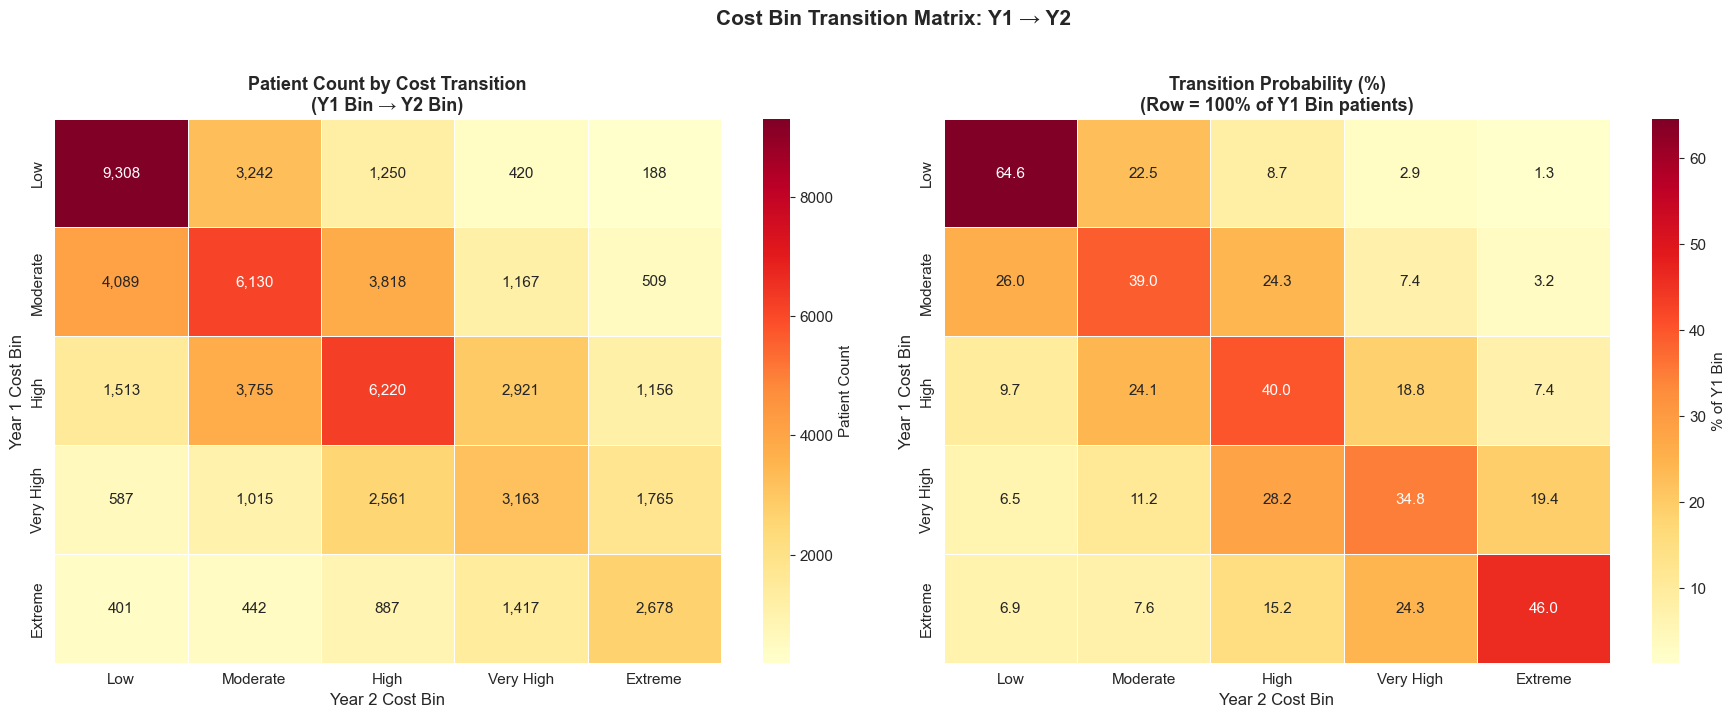


10-Class Summary (Y1_Level × Direction):
  Low_Improve     : n= 4,089, Y1=$      505, Y2=$       21, CV=1.85
  Low_Stable      : n=15,438, Y1=$      239, Y2=$      236, CV=1.45
  Low_MildRise    : n= 7,060, Y1=$      380, Y2=$    1,633, CV=0.82
  Low_Jumper      : n= 3,534, Y1=$      333, Y2=$   14,002, CV=2.04
  Mid_Improve     : n= 5,268, Y1=$    2,589, Y2=$      484, CV=0.83
  Mid_Stable      : n= 6,220, Y1=$    2,854, Y2=$    2,923, CV=0.40
  Mid_Escalate    : n= 4,077, Y1=$    3,184, Y2=$   18,232, CV=1.76
  High_Improve    : n= 7,310, Y1=$   21,374, Y2=$    3,675, CV=1.07
  High_Stable     : n= 5,841, Y1=$   28,078, Y2=$   29,058, CV=1.28
  High_Escalate   : n= 1,765, Y1=$   10,261, Y2=$   38,199, CV=0.89


In [6]:
# Transition Heatmap: Y1 Bin → Y2 Bin
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Count heatmap
ax1 = axes[0]
trans_matrix = pd.crosstab(df['Y1_BIN'], df['Y2_BIN'])
trans_matrix.index = [BIN_NAMES[i] for i in trans_matrix.index]
trans_matrix.columns = [BIN_NAMES[i] for i in trans_matrix.columns]

sns.heatmap(trans_matrix, annot=True, fmt=',d', cmap='YlOrRd', ax=ax1,
            linewidths=0.5, cbar_kws={'label': 'Patient Count'})
ax1.set_xlabel('Year 2 Cost Bin', fontsize=12)
ax1.set_ylabel('Year 1 Cost Bin', fontsize=12)
ax1.set_title('Patient Count by Cost Transition\n(Y1 Bin → Y2 Bin)', fontsize=13, fontweight='bold')

# Panel 2: Percentage heatmap (row-normalized)
ax2 = axes[1]
trans_pct = pd.crosstab(df['Y1_BIN'], df['Y2_BIN'], normalize='index') * 100
trans_pct.index = [BIN_NAMES[i] for i in trans_pct.index]
trans_pct.columns = [BIN_NAMES[i] for i in trans_pct.columns]

sns.heatmap(trans_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2,
            linewidths=0.5, cbar_kws={'label': '% of Y1 Bin'})
ax2.set_xlabel('Year 2 Cost Bin', fontsize=12)
ax2.set_ylabel('Year 1 Cost Bin', fontsize=12)
ax2.set_title('Transition Probability (%)\n(Row = 100% of Y1 Bin patients)', fontsize=13, fontweight='bold')

plt.suptitle('Cost Bin Transition Matrix: Y1 → Y2', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'transition_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats for 10-class system
print(f"\n10-Class Summary (Y1_Level × Direction):")
for t, name in CLASS_NAMES.items():
    mask = df['RISK_TIER'] == t
    n = mask.sum()
    mean_y1 = df.loc[mask, 'COST_Y1_ADJ'].mean()
    mean_y2 = df.loc[mask, 'COST_Y2_ADJ'].mean()
    std_y2 = df.loc[mask, 'COST_Y2_ADJ'].std()
    cv = std_y2 / (mean_y2 + 1)
    print(f"  {name:16s}: n={n:>6,}, Y1=${mean_y1:>9,.0f}, Y2=${mean_y2:>9,.0f}, CV={cv:.2f}")

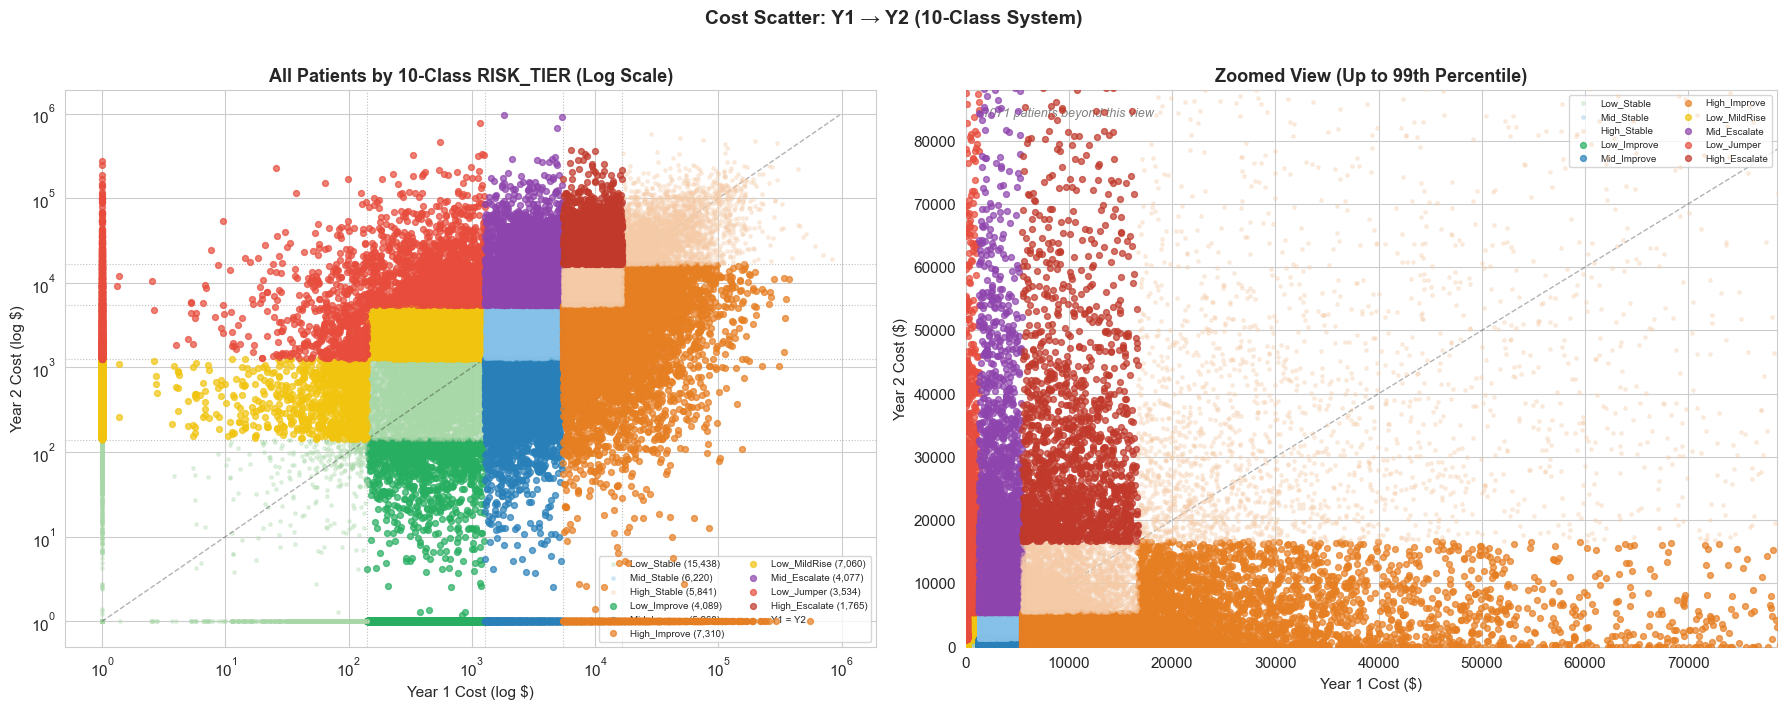

In [7]:
# Viz: Cost Scatter — Color by 10-Class RISK_TIER (Y1 Level × Direction)
class_colors = {
    0: '#27ae60', 1: '#a8d8a8', 2: '#f1c40f', 3: '#e74c3c',
    4: '#2980b9', 5: '#85c1e9', 6: '#8e44ad',
    7: '#e67e22', 8: '#f5cba7', 9: '#c0392b',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel 1: Log-Log Scatter ---
ax1 = axes[0]
x_log = df['COST_Y1_ADJ'].clip(lower=1)
y_log = df['COST_Y2_ADJ'].clip(lower=1)

draw_order = [1, 5, 8, 0, 4, 7, 2, 6, 3, 9]
for t in draw_order:
    mask = df['RISK_TIER'] == t
    if mask.sum() == 0: continue
    is_bg = t in [1, 5, 8]
    ax1.scatter(x_log[mask], y_log[mask], c=class_colors[t], alpha=0.3 if is_bg else 0.7,
                s=6 if is_bg else 18, zorder=t+1, label=f'{CLASS_NAMES[t]} ({mask.sum():,})')

for threshold in bp:
    ax1.axhline(y=max(threshold, 1), color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax1.axvline(x=max(threshold, 1), color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

lims = [1, max(x_log.max(), y_log.max())]
ax1.plot(lims, lims, 'k--', alpha=0.3, linewidth=1, label='Y1 = Y2')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Year 1 Cost (log $)', fontsize=11)
ax1.set_ylabel('Year 2 Cost (log $)', fontsize=11)
ax1.set_title('All Patients by 10-Class RISK_TIER (Log Scale)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=7, ncol=2)

# --- Panel 2: Zoomed Linear View ---
ax2 = axes[1]
x_cap = df['COST_Y1_ADJ'].quantile(0.99)
y_cap = df['COST_Y2_ADJ'].quantile(0.99)

for t in draw_order:
    mask = df['RISK_TIER'] == t
    if mask.sum() == 0: continue
    is_bg = t in [1, 5, 8]
    ax2.scatter(df.loc[mask, 'COST_Y1_ADJ'], df.loc[mask, 'COST_Y2_ADJ'],
                c=class_colors[t], alpha=0.3 if is_bg else 0.7,
                s=6 if is_bg else 18, zorder=t+1, label=CLASS_NAMES[t])

ax2.plot([0, max(x_cap, y_cap)], [0, max(x_cap, y_cap)], 'k--', alpha=0.3, linewidth=1)
ax2.set_xlim(0, x_cap); ax2.set_ylim(0, y_cap)
ax2.set_xlabel('Year 1 Cost ($)', fontsize=11)
ax2.set_ylabel('Year 2 Cost ($)', fontsize=11)
ax2.set_title('Zoomed View (Up to 99th Percentile)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=7, ncol=2)

n_beyond = ((df['COST_Y1_ADJ'] > x_cap) | (df['COST_Y2_ADJ'] > y_cap)).sum()
ax2.text(0.02, 0.97, f'{n_beyond} patients beyond this view', transform=ax2.transAxes,
         fontsize=9, va='top', color='gray', style='italic')

plt.suptitle('Cost Scatter: Y1 → Y2 (10-Class System)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'transition_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

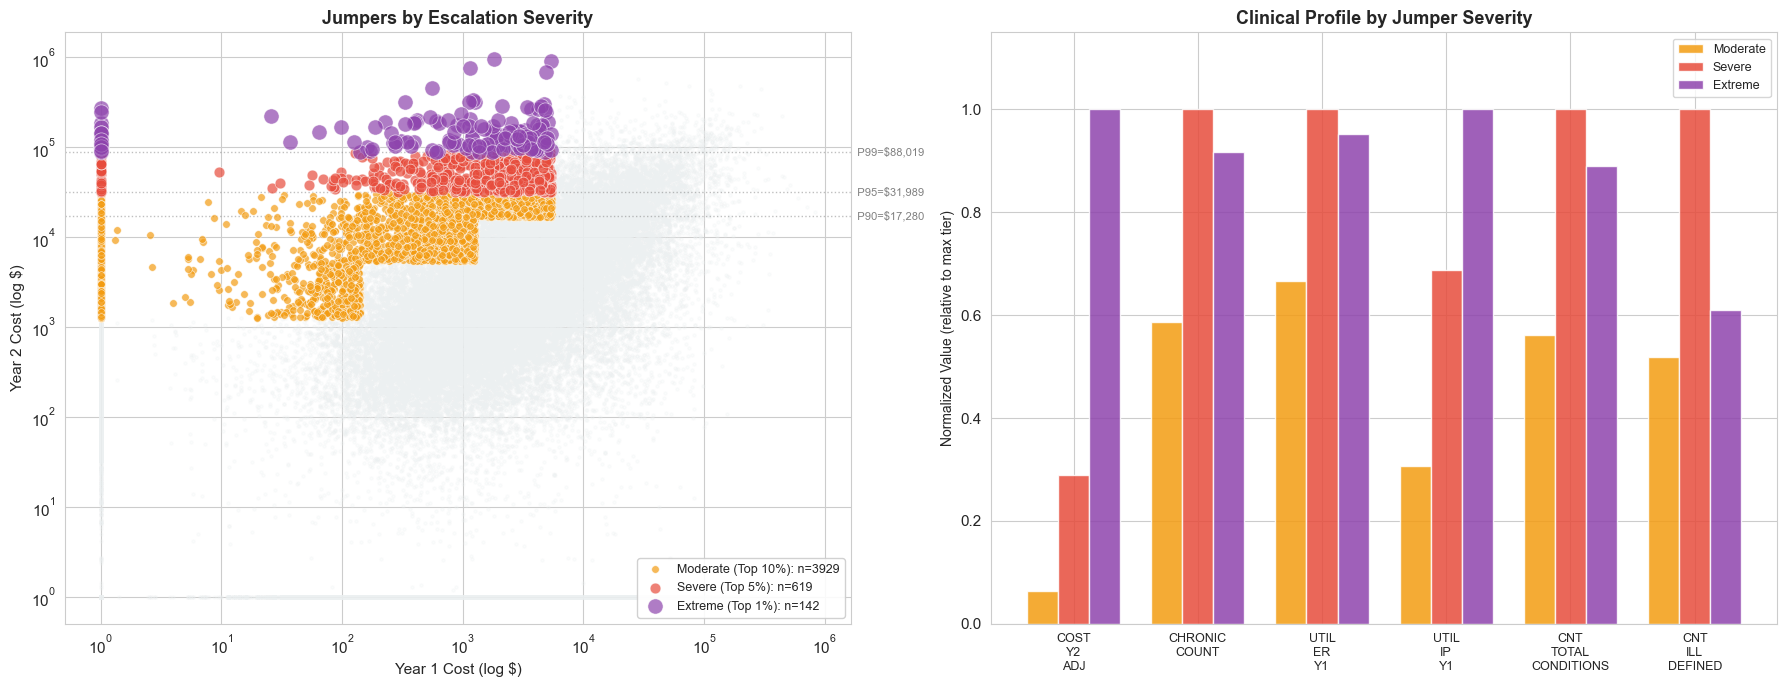

Jumper Tier Summary:
                    Count Mean_Y1_Cost Mean_Y2_Cost Median_Y2_Cost Max_Y2_Cost  Mean_Chronic
JUMP_TIER                                                                                   
Moderate (Top 10%)   3929         $822      $10,833         $8,021     $31,933      0.588954
Severe (Top 5%)       619       $2,185      $49,196        $45,362     $87,973      1.004847
Extreme (Top 1%)      142       $1,892     $169,874       $132,533    $956,768      0.922535


In [8]:
# Deep Dive: Jumper Tiers by Cost Escalation Magnitude
jumpers = df[df['IS_JUMPER'] == 1].copy()

# Define Jump Tiers based on Y2 cost
y2_p90 = df['COST_Y2_ADJ'].quantile(0.90)
y2_p95 = df['COST_Y2_ADJ'].quantile(0.95)
y2_p99 = df['COST_Y2_ADJ'].quantile(0.99)

def classify_jump(y2_cost):
    if y2_cost >= y2_p99:
        return 'Extreme (Top 1%)'
    elif y2_cost >= y2_p95:
        return 'Severe (Top 5%)'
    else:
        return 'Moderate (Top 10%)'

jumpers['JUMP_TIER'] = jumpers['COST_Y2_ADJ'].apply(classify_jump)

# Tier styling
tier_config = {
    'Moderate (Top 10%)': {'color': '#f39c12', 'size': 30, 'order': 0},
    'Severe (Top 5%)':    {'color': '#e74c3c', 'size': 60, 'order': 1},
    'Extreme (Top 1%)':   {'color': '#8e44ad', 'size': 120, 'order': 2},
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel 1: Jumper Scatter by Tier (Log Scale) ---
ax1 = axes[0]

# Background: all non-jumpers
non_j = df[df['IS_JUMPER'] == 0]
ax1.scatter(non_j['COST_Y1_ADJ'].clip(lower=1), non_j['COST_Y2_ADJ'].clip(lower=1),
            c='#ecf0f1', alpha=0.2, s=5, zorder=1)

# Plot each jumper tier (moderate first so extreme is on top)
for tier in ['Moderate (Top 10%)', 'Severe (Top 5%)', 'Extreme (Top 1%)']:
    cfg = tier_config[tier]
    subset = jumpers[jumpers['JUMP_TIER'] == tier]
    ax1.scatter(subset['COST_Y1_ADJ'].clip(lower=1), subset['COST_Y2_ADJ'].clip(lower=1),
                c=cfg['color'], s=cfg['size'], alpha=0.7, edgecolors='white', linewidth=0.5,
                label=f"{tier}: n={len(subset)}", zorder=3 + cfg['order'])

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.axhline(y=y2_p90, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.axhline(y=y2_p95, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.axhline(y=y2_p99, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Label thresholds on right edge
for val, label in [(y2_p90, 'P90'), (y2_p95, 'P95'), (y2_p99, 'P99')]:
    ax1.text(ax1.get_xlim()[1] if ax1.get_xlim()[1] > 0 else 500000, val,
             f'  {label}=${val:,.0f}', fontsize=8, va='center', color='gray')

ax1.set_xlabel('Year 1 Cost (log $)', fontsize=11)
ax1.set_ylabel('Year 2 Cost (log $)', fontsize=11)
ax1.set_title('Jumpers by Escalation Severity', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9, framealpha=0.9)

# --- Panel 2: Jumper Profile Comparison (Bar Chart) ---
ax2 = axes[1]

# Compare key features across tiers
profile_feats = ['COST_Y2_ADJ', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 
                 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED']
profile_feats = [f for f in profile_feats if f in jumpers.columns]

tier_means = jumpers.groupby('JUMP_TIER')[profile_feats].mean()
# Reorder rows
tier_order = ['Moderate (Top 10%)', 'Severe (Top 5%)', 'Extreme (Top 1%)']
tier_means = tier_means.reindex([t for t in tier_order if t in tier_means.index])

# Normalize each feature to [0,1] for comparison
tier_norm = tier_means.copy()
for col in tier_norm.columns:
    col_max = tier_norm[col].max()
    if col_max > 0:
        tier_norm[col] = tier_norm[col] / col_max

# Plot grouped bar chart
x = np.arange(len(profile_feats))
width = 0.25
colors_bar = ['#f39c12', '#e74c3c', '#8e44ad']

for i, (tier, color) in enumerate(zip(tier_order, colors_bar)):
    if tier in tier_norm.index:
        vals = tier_norm.loc[tier].values
        bars = ax2.bar(x + i * width, vals, width, label=tier.split('(')[0].strip(), 
                       color=color, edgecolor='white', alpha=0.85)

ax2.set_xticks(x + width)
ax2.set_xticklabels([f.replace('_', '\n') for f in profile_feats], fontsize=9)
ax2.set_ylabel('Normalized Value (relative to max tier)', fontsize=10)
ax2.set_title('Clinical Profile by Jumper Severity', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'jumper_tiers_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("Jumper Tier Summary:")
summary = jumpers.groupby('JUMP_TIER').agg(
    Count=('COST_Y2_ADJ', 'size'),
    Mean_Y1_Cost=('COST_Y1_ADJ', 'mean'),
    Mean_Y2_Cost=('COST_Y2_ADJ', 'mean'),
    Median_Y2_Cost=('COST_Y2_ADJ', 'median'),
    Max_Y2_Cost=('COST_Y2_ADJ', 'max'),
    Mean_Chronic=('CHRONIC_COUNT', 'mean') if 'CHRONIC_COUNT' in jumpers.columns else ('COST_Y1_ADJ', 'size'),
).reindex([t for t in tier_order if t in jumpers['JUMP_TIER'].values])

for col in ['Mean_Y1_Cost', 'Mean_Y2_Cost', 'Median_Y2_Cost', 'Max_Y2_Cost']:
    if col in summary.columns:
        summary[col] = summary[col].apply(lambda x: f'${x:,.0f}')

print(summary.to_string())

### Interpretation: Jumper Tier Analysis (Aligned with 2D Target)

**Definition used throughout this project:**
- `IS_JUMPER = 1` when `DELTA_BIN >= 2` (cost-bin increase of at least two bins)
- This is the same escalation concept used in `Low_Jumper` inside the 10-class `RISK_TIER` target

**What the figure above shows:**
- **Left panel (log-log scatter):** Non-jumpers are gray background points. Jumpers are overlaid and split by Y2 severity (Top 10%, Top 5%, Top 1%).
- **Right panel (normalized profiles):** Compares clinical/utilization signatures across jumper severity tiers.

**How to read it:**
1. If jumper points concentrate in low-Y1/high-Y2 space, escalation is genuinely sharp, not just high persistent spend.
2. If Severe/Extreme jumpers have higher chronic/utilization burden than Moderate jumpers, Year 1 signals exist before the jump.
3. Overlap with non-jumpers indicates limits of rule-based definitions and motivates probabilistic modeling in Stage 1.

**Modeling implication:**
- Stage 1 predicts the full 10-class transition pattern.
- Stage 2 then models cost *within* those transition classes, rather than treating jumpers as a separate disconnected target.

### 8.2 Feature "Warning Signals"

What distinguishes **Jumpers** from **Stable Low** patients? We compare their Year 1 features to find early indicators.

**Interpretation:**
- A **Relative Risk Ratio > 1** means Jumpers have *higher* average values than Stable Low patients.
- Features with the highest ratios are the strongest "early warning" signals.

In [9]:
# Compare Jumpers vs Stable Low
compare_df = df[(df['IS_JUMPER'] == 1) | (df['IS_STABLE_LOW'] == 1)].copy()

# Features to Compare (only use columns that exist)
candidate_feats = [
    # Demographics & Health Status
    'AGE_Y1', 'CHRONIC_COUNT', 'MNHLTH_RD1', 'RTHLTH_RD1',
    # Healthcare Utilization
    'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1',
    # Condition Complexity
    'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED',
    # Chronic Disease Flags
    'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG',
    # Medication Patterns (NEW)
    'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'POLYPHARMACY_FLAG',
    'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
    'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'TOTAL_RX_COST_Y1'
]
features_to_check = [c for c in candidate_feats if c in compare_df.columns]

print(f"Analyzing {compare_df['IS_JUMPER'].sum()} 'Jumpers' vs {compare_df['IS_STABLE_LOW'].sum()} 'Stable Low' patients.")
print(f"Features Compared: {features_to_check}")

# Calculate Mean Differences
comparison = compare_df.groupby('IS_JUMPER')[features_to_check].mean().T
comparison.columns = ['Stable_Low_Avg', 'Jumper_Avg']
comparison['Rel_Risk_Ratio'] = comparison['Jumper_Avg'] / (comparison['Stable_Low_Avg'] + 0.001)

# Save Table
comparison_sorted = comparison.sort_values('Rel_Risk_Ratio', ascending=False)
comparison_sorted.to_csv(REPORT_DIR / 'tables' / 'feature_risk_ratios.csv')
print(f"Saved feature risk ratios to {REPORT_DIR / 'tables' / 'feature_risk_ratios.csv'}")

display(comparison_sorted.style.background_gradient(cmap='Reds', subset=['Rel_Risk_Ratio']))

Analyzing 4690 'Jumpers' vs 22769 'Stable Low' patients.
Features Compared: ['AGE_Y1', 'CHRONIC_COUNT', 'MNHLTH_RD1', 'RTHLTH_RD1', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'POLYPHARMACY_FLAG', 'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'TOTAL_RX_COST_Y1']
Saved feature risk ratios to ../reports/tables/feature_risk_ratios.csv


,Stable_Low_Avg,Jumper_Avg,Rel_Risk_Ratio
TOTAL_RX_COST_Y1,29.269372,442.672207,15.123559
POLYPHARMACY_FLAG,0.022311,0.189765,8.140584
CNT_RX_Y1,1.326716,7.109595,5.354755
UTIL_RX_Y1,1.303351,5.965885,4.573834
HAS_PAIN_RX,0.017919,0.082090,4.338978
HAS_GI_RX,0.039396,0.174414,4.317632
CNT_UNIQUE_DRUGS,0.566648,2.445416,4.307982
HAS_CARDIOVASCULAR_RX,0.067680,0.230064,3.349808
UTIL_OB_Y1,0.737187,2.413006,3.268830
DIAB_Y1_FLAG,0.024902,0.083369,3.218592


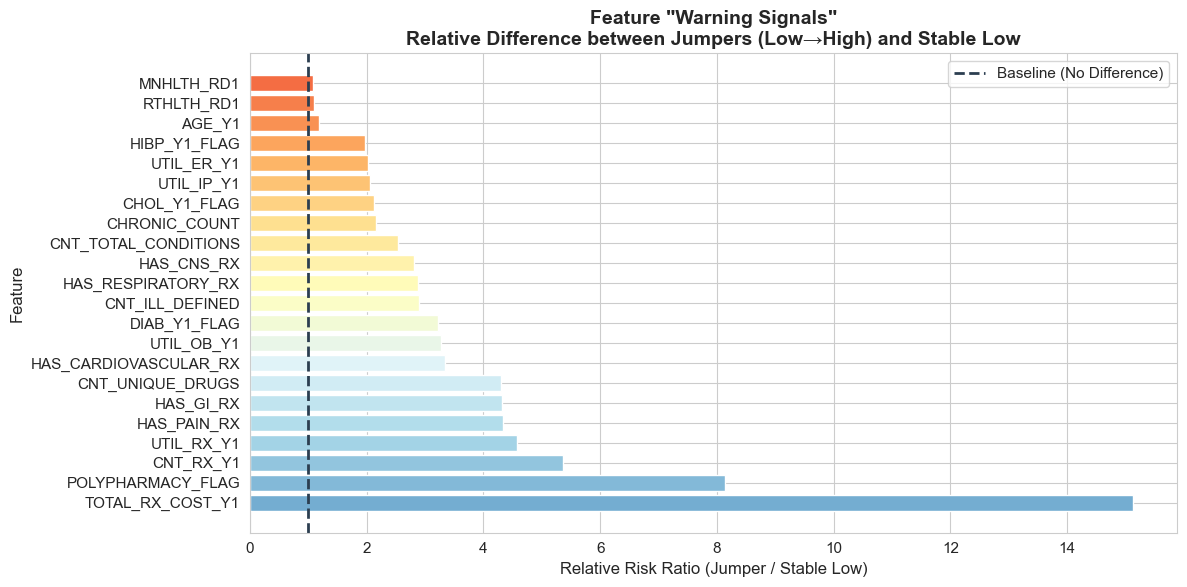

In [10]:
# Visualize Warning Signals
fig, ax = plt.subplots(figsize=(12, 6))

sorted_data = comparison_sorted.reset_index()
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(sorted_data)))

bars = ax.barh(sorted_data['index'], sorted_data['Rel_Risk_Ratio'], color=colors)
ax.axvline(x=1.0, color='#2c3e50', linestyle='--', linewidth=2, label='Baseline (No Difference)')

ax.set_xlabel('Relative Risk Ratio (Jumper / Stable Low)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature "Warning Signals"\nRelative Difference between Jumpers (Low→High) and Stable Low', 
             fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'exploratory_risk_ratios.png', dpi=150)
plt.show()

### Interpretation: Warning Signal Analysis

The comparison above quantifies which Year 1 features differ between `IS_JUMPER=1` and `IS_STABLE_LOW=1` groups.

Use this table as directional evidence, not a causal claim:
1. Higher chronic burden and diagnosis complexity suggest latent disease progression risk.
2. Higher Rx/utilization intensity can indicate unresolved clinical complexity before large cost jumps.
3. Ill-defined condition counts can flag diagnostic uncertainty that later resolves into high-cost episodes.

**Important guardrail:**
- These are descriptive contrasts from observational data. They should inform feature design and hypothesis generation, not be interpreted as intervention effects.

---
## 9. Patient Phenotype Clustering
We cluster patients based on **multi-dimensional profiles** combining:
- **Utilization Patterns**: ER, Inpatient, Office, Rx
- **Clinical Complexity**: Chronic conditions, Total conditions
- **Undiagnosed Signals**: Count of ill-defined diagnoses
- **Demographics**: Age

This creates "Care Phenotypes" like:
- **ER Frequent Flyers**: High ER, low primary care
- **Medication Managers**: Many Rx, few visits
- **Complex Chronic**: Multiple conditions, high utilization

### K Selection Strategy (Combined Approach)

**Why NOT just use max Silhouette?**
- Silhouette Score almost always peaks at k=2 (trivial binary split)
- k=2 is not clinically meaningful for patient segmentation

**Our Combined Method:**
1. **Elbow Detection**: Find where Inertia curve "bends" using curvature analysis
2. **Silhouette Validation**: Ensure the chosen k has acceptable cluster separation (> 0.15)
3. **Domain Constraint**: For healthcare phenotypes, k should be in range [3, 7]

In [11]:
# Expanded Features for Clustering (including Medication patterns)
cluster_candidates = [
    # Demographics
    'AGE_Y1',
    # Healthcare Utilization
    'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1',
    # Condition Complexity
    'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CHRONIC_COUNT',
    # Medication Patterns (NEW - clinically meaningful)
    'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG',
    'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
    'HAS_RESPIRATORY_RX', 'HAS_GI_RX',
    # Self-reported Health Status
    'MNHLTH_RD1', 'RTHLTH_RD1'
]

# Use only available columns
cluster_feats = [c for c in cluster_candidates if c in df.columns]
print(f"Clustering Features ({len(cluster_feats)}): {cluster_feats}")

# Prepare Data
X_cluster = df[cluster_feats].copy()
for col in X_cluster.columns:
    if pd.api.types.is_numeric_dtype(X_cluster[col]):
        X_cluster[col] = X_cluster[col].fillna(X_cluster[col].median())
    else:
        X_cluster[col] = X_cluster[col].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Optimization: Run K-Means for range of k
print("\nRunning K-Means Optimization...")
inertia = []
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    
    if len(df) > 10000:
        sil = silhouette_score(X_scaled, km.labels_, sample_size=5000)
    else:
        sil = silhouette_score(X_scaled, km.labels_)
    sil_scores.append(sil)
    print(f"  k={k}: Inertia={km.inertia_:,.0f}, Silhouette={sil:.3f}")

Clustering Features (18): ['AGE_Y1', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CHRONIC_COUNT', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG', 'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'MNHLTH_RD1', 'RTHLTH_RD1']

Running K-Means Optimization...
  k=2: Inertia=802,336, Silhouette=0.395
  k=3: Inertia=738,339, Silhouette=0.330
  k=4: Inertia=696,926, Silhouette=0.177
  k=5: Inertia=662,367, Silhouette=0.153
  k=6: Inertia=636,553, Silhouette=0.166
  k=7: Inertia=609,761, Silhouette=0.161
  k=8: Inertia=587,193, Silhouette=0.163
  k=9: Inertia=562,238, Silhouette=0.172


In [12]:
def find_elbow(k_values, inertia_values):
    """
    Find the elbow point using the "Kneedle" algorithm.
    
    The elbow is where the rate of decrease sharply changes.
    We use the point of maximum curvature (second derivative).
    """
    k_arr = np.array(list(k_values))
    inertia_arr = np.array(inertia_values)
    
    # Normalize to [0, 1]
    k_norm = (k_arr - k_arr.min()) / (k_arr.max() - k_arr.min())
    inertia_norm = (inertia_arr - inertia_arr.min()) / (inertia_arr.max() - inertia_arr.min())
    
    # Calculate distance from each point to the line connecting first and last points
    # Line: from (k_norm[0], inertia_norm[0]) to (k_norm[-1], inertia_norm[-1])
    p1 = np.array([k_norm[0], inertia_norm[0]])
    p2 = np.array([k_norm[-1], inertia_norm[-1]])
    
    distances = []
    for i in range(len(k_norm)):
        p = np.array([k_norm[i], inertia_norm[i]])
        # Distance from point to line
        d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)
    
    # The elbow is the point with maximum distance
    elbow_idx = np.argmax(distances)
    return k_arr[elbow_idx]

# Find elbow point
elbow_k = find_elbow(k_range, inertia)

# Apply domain constraints: k should be in [3, 7] for healthcare phenotypes
MIN_K, MAX_K = 3, 7
if elbow_k < MIN_K:
    elbow_k = MIN_K
    print(f"Elbow k={elbow_k} is too small. Adjusting to minimum domain constraint k={MIN_K}.")
elif elbow_k > MAX_K:
    elbow_k = MAX_K
    print(f"Elbow k={elbow_k} is too large. Adjusting to maximum domain constraint k={MAX_K}.")

# Validate with Silhouette (should be > 0.15 for acceptable separation)
k_idx = list(k_range).index(elbow_k)
elbow_sil = sil_scores[k_idx]

if elbow_sil < 0.15:
    print(f"Warning: Silhouette score at k={elbow_k} is low ({elbow_sil:.3f}).")
    print("Consider reviewing cluster quality or trying different features.")

print(f"\n=== Optimal k Selection ===")
print(f"Elbow Method suggests: k = {elbow_k}")
print(f"Silhouette Score at k={elbow_k}: {elbow_sil:.3f}")
print(f"Domain constraint: [{MIN_K}, {MAX_K}]")
print(f"\nFinal Selected k = {elbow_k}")


=== Optimal k Selection ===
Elbow Method suggests: k = 5
Silhouette Score at k=5: 0.153
Domain constraint: [3, 7]

Final Selected k = 5


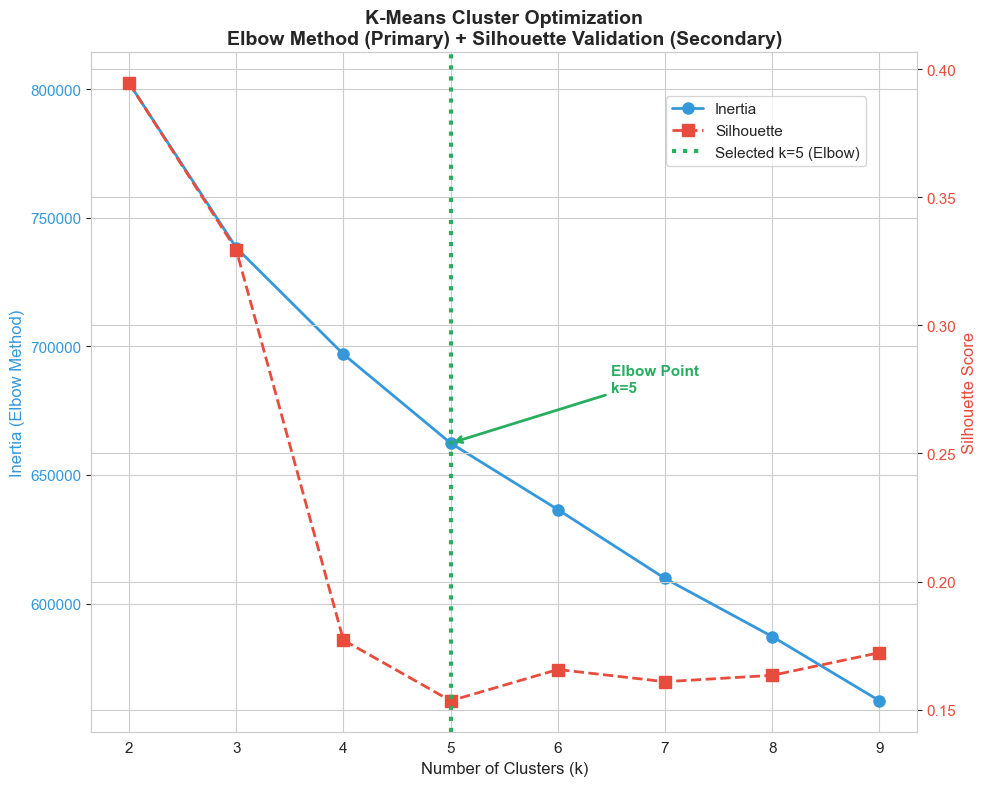

In [13]:
# Dual Axis Plot with Elbow Highlight
fig, ax1 = plt.subplots(figsize=(10, 8))

color1 = '#3498db'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Elbow Method)', color=color1, fontsize=12)
ax1.plot(k_range, inertia, marker='o', color=color1, linewidth=2, markersize=8, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=12)
ax2.plot(k_range, sil_scores, marker='s', linestyle='--', color=color2, linewidth=2, markersize=8, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

# Highlight the selected k (Elbow-based, not max Silhouette)
ax2.axvline(x=elbow_k, color='#27ae60', linestyle=':', linewidth=3, label=f'Selected k={elbow_k} (Elbow)')

# Add annotation
ax1.annotate(f'Elbow Point\nk={elbow_k}', xy=(elbow_k, inertia[k_idx]), 
             xytext=(elbow_k + 1.5, inertia[k_idx] + 20000),
             fontsize=11, color='#27ae60', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))

plt.title('K-Means Cluster Optimization\nElbow Method (Primary) + Silhouette Validation (Secondary)', 
          fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'kmeans_optimization.png', dpi=150)
plt.show()



### Interpretation: K-Means Optimization (Elbow & Silhouette)

**What the dual-axis plot shows:**
- **Blue line (Inertia)**: Within-cluster sum of squares — lower is better, but decreasing returns as k increases
- **Orange line (Silhouette)**: Cluster separation quality — higher is better, ranges from -1 to +1
- **Green vertical line**: Optimal k detected by the Kneedle algorithm (elbow point)

**How to read this:**
1. **Elbow Method**: Look for where inertia curve "bends" — adding more clusters gives diminishing returns
2. **Silhouette Score**: Confirms the elbow choice; a local peak suggests natural cluster structure
3. **Trade-off**: More clusters = lower inertia but may overfit; fewer clusters = simpler but may miss patterns

**Why we chose k=5 (or the detected value):**
- Balances complexity and interpretability
- Each cluster should represent a distinct "Care Phenotype"
- Clinically meaningful groupings are more useful than statistically optimal but uninterpretable ones

**Important Note:**
- If no clear elbow exists, the data may not have strong natural clusters
- PCA visualization helps confirm whether clusters are visually separable
- DBSCAN (next section) can find clusters of arbitrary shape and identify outliers

In [14]:
# Apply Final Clustering with Elbow-selected k
k_final = elbow_k
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['CARE_CLUSTER'] = km_final.fit_predict(X_scaled)

print(f"Applied k={k_final} clusters.")
print(f"\nCluster Distribution:\n{df['CARE_CLUSTER'].value_counts().sort_index()}")

Applied k=5 clusters.

Cluster Distribution:
CARE_CLUSTER
0    26258
1     9219
2     3248
3     6217
4    15660
Name: count, dtype: int64


In [15]:
# Cluster Profile Analysis
cluster_profiles = df.groupby('CARE_CLUSTER')[cluster_feats + ['COST_Y2_ADJ']].mean()
cluster_profiles['COUNT'] = df.groupby('CARE_CLUSTER').size()

print("\n=== Care Phenotype Profiles ===")
display(cluster_profiles.round(2).style.background_gradient(cmap='Blues', axis=0))

# Save profiles
cluster_profiles.to_csv(REPORT_DIR / 'tables' / 'care_cluster_profiles.csv')
print(f"\nSaved cluster profiles to {REPORT_DIR / 'tables' / 'care_cluster_profiles.csv'}")


=== Care Phenotype Profiles ===


,AGE_Y1,UTIL_ER_Y1,UTIL_IP_Y1,UTIL_OB_Y1,UTIL_RX_Y1,CNT_TOTAL_CONDITIONS,CNT_ILL_DEFINED,CHRONIC_COUNT,CNT_UNIQUE_DRUGS,TOTAL_RX_COST_Y1,POLYPHARMACY_FLAG,HAS_CARDIOVASCULAR_RX,HAS_CNS_RX,HAS_PAIN_RX,HAS_RESPIRATORY_RX,HAS_GI_RX,MNHLTH_RD1,RTHLTH_RD1,COST_Y2_ADJ,COUNT
CARE_CLUSTER,,,,,,,,,,,,,,,,,,,,
0,37.510000,0.090000,0.030000,2.410000,1.770000,1.270000,0.080000,0.180000,0.750000,183.370000,0.010000,0.040000,0.130000,0.020000,0.040000,0.020000,1.310000,1.540000,2680.520000,26258
1,63.290000,0.200000,0.100000,7.500000,24.650000,4.980000,0.280000,1.940000,7.740000,2185.690000,0.820000,0.880000,0.430000,0.100000,0.130000,0.870000,2.110000,2.770000,12165.860000,9219
2,60.620000,1.080000,0.650000,23.170000,70.440000,12.410000,1.460000,1.900000,16.520000,10206.620000,0.990000,0.860000,0.890000,0.550000,0.440000,0.760000,2.910000,3.690000,33969.440000,3248
3,47.100000,0.510000,0.170000,11.990000,19.880000,5.780000,0.580000,0.640000,6.750000,1798.700000,0.790000,0.330000,0.830000,0.510000,0.340000,0.090000,2.510000,2.770000,11551.830000,6217
4,43.520000,0.160000,0.060000,2.820000,3.220000,1.910000,0.120000,0.560000,1.110000,297.600000,0.010000,0.130000,0.190000,0.030000,0.040000,0.060000,2.700000,3.060000,3775.240000,15660



Saved cluster profiles to ../reports/tables/care_cluster_profiles.csv


### Interpretation: K-Means Cluster Profiles ("Care Phenotypes")

**What the cluster profile table shows:**
- Each row represents a cluster (patient group)
- Columns show mean values for key features within each cluster
- `COST_Y2_ADJ` shows the average Year 2 cost for patients in that cluster
- `COUNT` shows how many patients belong to each cluster

**How to interpret each cluster (example phenotypes):**

| Cluster | Typical Profile | Clinical Label |
|---------|-----------------|----------------|
| **Low Age, Low Chronic, Low Util** | Young, healthy, minimal healthcare use | "Healthy Young Adults" |
| **High Age, High Chronic, High RX** | Elderly with multiple conditions, many medications | "Complex Chronic" |
| **Moderate Age, High ER, Low Office** | ER-dependent, poor primary care engagement | "Crisis Care Seekers" |
| **High Office Visits, Low ER** | Regular check-ups, preventive orientation | "Engaged Patients" |

**Why this matters:**
1. **Actionable segments**: Each cluster suggests different interventions
2. **Cost drivers**: Identify which phenotypes drive the most expenditure
3. **Feature for modeling**: `CLUSTER_KMEANS` becomes a categorical feature encoding care pattern
4. **Clinical validity**: Clusters should align with clinician intuition about patient types

**Validation check**: Compare mean `COST_Y2_ADJ` across clusters — if clusters have similar costs, they may not be capturing meaningful variation.

---
## 9.1 Alternative: DBSCAN Clustering (Density-Based)

### Why this section was stabilized

Running DBSCAN on the full cohort can cause kernel crashes on typical laptop memory because density-based neighbor searches scale poorly with sample size in this feature space.

### Stabilized approach used here

1. Fit DBSCAN on a reproducible random subset when the cohort is large.
2. Propagate labels to remaining rows using nearest labeled neighbors within `eps`.
3. Keep unmatched rows as noise (`-1`).

This preserves exploratory value (natural clusters + outlier detection) while avoiding memory-related kernel failure.

Large cohort detected (n=60,602).
Using subset for DBSCAN fit: n=15,000.


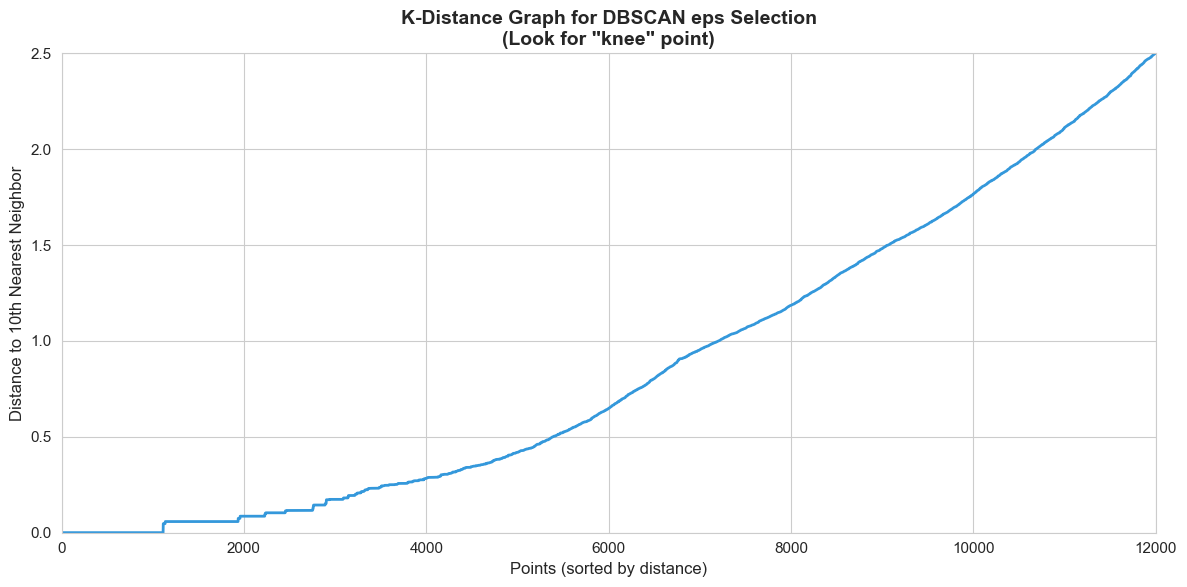


Estimated eps (90th percentile): 3.251


In [16]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Step 1: Robust eps estimation on a bounded sample to avoid kernel OOM
min_samples = 10  # Reasonable for healthcare data
MAX_DBSCAN_POINTS = 15000

n_total = len(X_scaled)
if n_total > MAX_DBSCAN_POINTS:
    rng = np.random.RandomState(42)
    dbscan_sample_idx = np.sort(rng.choice(n_total, size=MAX_DBSCAN_POINTS, replace=False))
    X_dbscan = X_scaled[dbscan_sample_idx]
    dbscan_is_sampled = True
    print(f"Large cohort detected (n={n_total:,}).")
    print(f"Using subset for DBSCAN fit: n={len(dbscan_sample_idx):,}.")
else:
    dbscan_sample_idx = np.arange(n_total)
    X_dbscan = X_scaled
    dbscan_is_sampled = False
    print(f"Using full cohort for DBSCAN fit: n={n_total:,}.")

# Calculate distances to k nearest neighbors on working matrix
nn = NearestNeighbors(n_neighbors=min_samples, algorithm='ball_tree')
nn.fit(X_dbscan)
distances, _ = nn.kneighbors(X_dbscan)

# Sort the distances to the k-th neighbor
k_distances = np.sort(distances[:, min_samples - 1])

# Plot k-distance graph
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(k_distances)), k_distances, color='#3498db', linewidth=2)
ax.set_xlabel('Points (sorted by distance)', fontsize=12)
ax.set_ylabel(f'Distance to {min_samples}th Nearest Neighbor', fontsize=12)
ax.set_title('K-Distance Graph for DBSCAN eps Selection\n(Look for "knee" point)', fontsize=14, fontweight='bold')

# Zoom to relevant region
cutoff = max(int(len(k_distances) * 0.8), 1)
ax.set_xlim(0, cutoff)
ax.set_ylim(0, k_distances[cutoff - 1])

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'dbscan_k_distance.png', dpi=150)
plt.show()

# Estimate eps from the upper tail of k-distances
eps_estimate = np.percentile(k_distances, 90)
print()
print(f"Estimated eps (90th percentile): {eps_estimate:.3f}")

In [17]:
# Step 2: Run DBSCAN on working matrix, then map labels back to full cohort
# n_jobs=1 is intentionally used for stability on limited-memory environments.
dbscan = DBSCAN(eps=eps_estimate, min_samples=min_samples, algorithm='ball_tree', n_jobs=1)
sample_labels = dbscan.fit_predict(X_dbscan)

# Initialize all rows as noise
labels_full = np.full(len(df), -1, dtype=int)
labels_full[dbscan_sample_idx] = sample_labels

# If sampled fit was used, propagate labels to non-sampled rows by nearest non-noise sampled point
if dbscan_is_sampled:
    all_idx = np.arange(len(df))
    nonsample_idx = all_idx[~np.isin(all_idx, dbscan_sample_idx)]
    core_mask = sample_labels != -1

    print(f"DBSCAN fitted on sample: {len(dbscan_sample_idx):,} rows")
    print(f"Rows to map back: {len(nonsample_idx):,}")

    if core_mask.any() and len(nonsample_idx) > 0:
        nn_map = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
        nn_map.fit(X_dbscan[core_mask])
        dists, inds = nn_map.kneighbors(X_scaled[nonsample_idx])

        nearest_labels = sample_labels[core_mask][inds[:, 0]]
        mapped_labels = np.where(dists[:, 0] <= eps_estimate, nearest_labels, -1)
        labels_full[nonsample_idx] = mapped_labels.astype(int)

        mapped_pct = (mapped_labels != -1).mean() * 100
        print(f"Mapped non-sampled rows to clusters within eps: {mapped_pct:.1f}%")
    else:
        print("No non-noise sampled cores available for mapping; non-sampled rows kept as noise.")

df['DBSCAN_CLUSTER'] = labels_full

# Analyze results
n_clusters_dbscan = len(set(df['DBSCAN_CLUSTER'])) - (1 if -1 in df['DBSCAN_CLUSTER'].values else 0)
n_noise = (df['DBSCAN_CLUSTER'] == -1).sum()
noise_pct = n_noise / len(df) * 100

print("=== DBSCAN Results ===")
print(f"eps = {eps_estimate:.3f}, min_samples = {min_samples}")
print(f"Number of Clusters: {n_clusters_dbscan}")
print(f"Noise Points: {n_noise:,} ({noise_pct:.1f}%)")
print()
print("Cluster Distribution:")
print(df['DBSCAN_CLUSTER'].value_counts().sort_index())

DBSCAN fitted on sample: 15,000 rows
Rows to map back: 45,602
Mapped non-sampled rows to clusters within eps: 95.2%
=== DBSCAN Results ===
eps = 3.251, min_samples = 10
Number of Clusters: 2
Noise Points: 3,035 (5.0%)

Cluster Distribution:
DBSCAN_CLUSTER
-1     3035
 0    52485
 1     5082
Name: count, dtype: int64


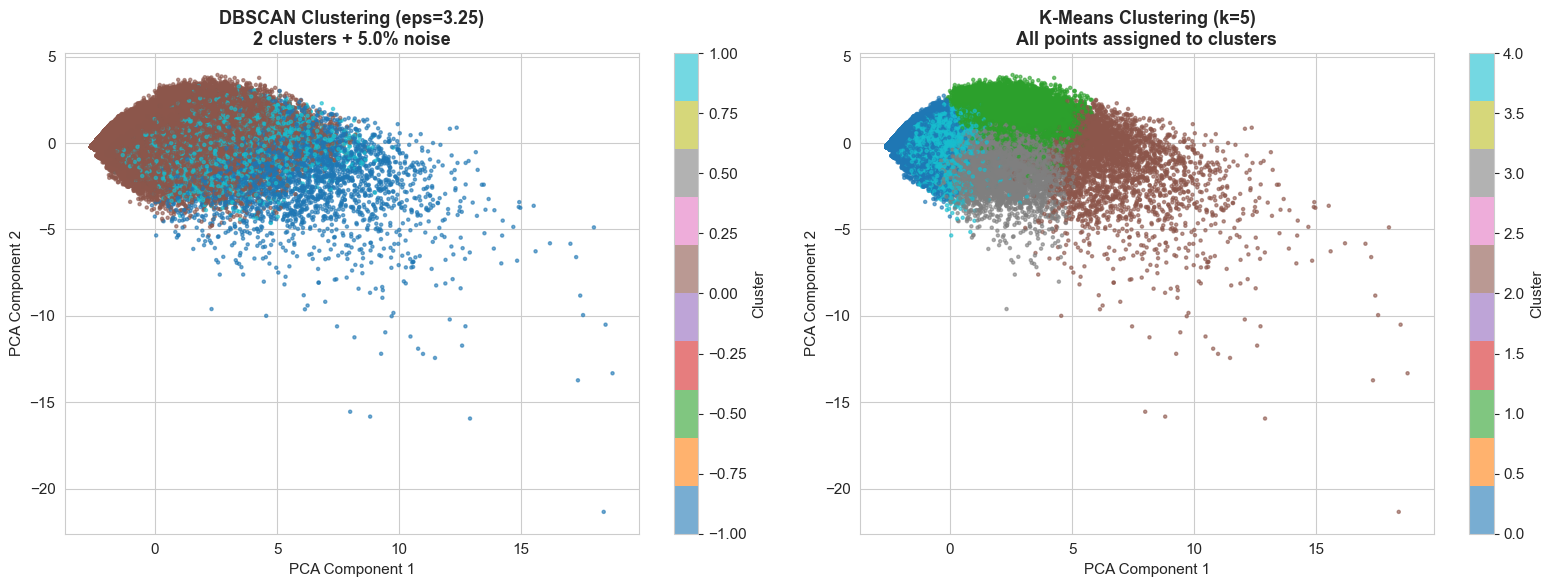

In [18]:
# Step 3: Visualize DBSCAN clusters using PCA
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN
ax1 = axes[0]
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], 
                       c=df['DBSCAN_CLUSTER'], cmap='tab10', s=5, alpha=0.6)
ax1.set_xlabel('PCA Component 1', fontsize=11)
ax1.set_ylabel('PCA Component 2', fontsize=11)
ax1.set_title(f'DBSCAN Clustering (eps={eps_estimate:.2f})\n{n_clusters_dbscan} clusters + {noise_pct:.1f}% noise', 
              fontsize=13, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# K-Means for comparison
ax2 = axes[1]
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], 
                       c=df['CARE_CLUSTER'], cmap='tab10', s=5, alpha=0.6)
ax2.set_xlabel('PCA Component 1', fontsize=11)
ax2.set_ylabel('PCA Component 2', fontsize=11)
ax2.set_title(f'K-Means Clustering (k={k_final})\nAll points assigned to clusters', 
              fontsize=13, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'dbscan_vs_kmeans.png', dpi=150)
plt.show()

In [19]:
# DBSCAN Cluster Profile Analysis
dbscan_profiles = df.groupby('DBSCAN_CLUSTER')[cluster_feats + ['COST_Y2_ADJ']].mean()
dbscan_profiles['COUNT'] = df.groupby('DBSCAN_CLUSTER').size()
dbscan_profiles['PCT'] = (dbscan_profiles['COUNT'] / len(df) * 100).round(1)

print("=== DBSCAN Cluster Profiles (Original Features) ===")
print("Note: Cluster -1 = Noise (atypical patients)\n")
display(dbscan_profiles.round(2).style.background_gradient(cmap='RdYlGn_r', axis=0, subset=['COST_Y2_ADJ']))

# Save profiles
dbscan_profiles.to_csv(REPORT_DIR / 'tables' / 'dbscan_cluster_profiles.csv')
print(f"\nSaved DBSCAN profiles to {REPORT_DIR / 'tables' / 'dbscan_cluster_profiles.csv'}")

=== DBSCAN Cluster Profiles (Original Features) ===
Note: Cluster -1 = Noise (atypical patients)



,AGE_Y1,UTIL_ER_Y1,UTIL_IP_Y1,UTIL_OB_Y1,UTIL_RX_Y1,CNT_TOTAL_CONDITIONS,CNT_ILL_DEFINED,CHRONIC_COUNT,CNT_UNIQUE_DRUGS,TOTAL_RX_COST_Y1,POLYPHARMACY_FLAG,HAS_CARDIOVASCULAR_RX,HAS_CNS_RX,HAS_PAIN_RX,HAS_RESPIRATORY_RX,HAS_GI_RX,MNHLTH_RD1,RTHLTH_RD1,COST_Y2_ADJ,COUNT,PCT
DBSCAN_CLUSTER,,,,,,,,,,,,,,,,,,,,,
-1,57.210000,1.430000,0.880000,26.730000,58.060000,10.470000,1.310000,1.500000,14.000000,10600.820000,0.890000,0.670000,0.800000,0.490000,0.420000,0.570000,2.780000,3.500000,34475.810000,3035,5.000000
0,44.030000,0.150000,0.050000,3.960000,7.520000,2.430000,0.170000,0.610000,2.390000,624.240000,0.190000,0.230000,0.260000,0.080000,0.000000,0.180000,1.940000,2.260000,5093.780000,52485,86.600000
1,50.170000,0.260000,0.060000,7.400000,20.720000,5.150000,0.370000,0.970000,7.090000,1775.330000,0.620000,0.430000,0.490000,0.190000,1.000000,0.320000,2.180000,2.680000,10199.080000,5082,8.400000



Saved DBSCAN profiles to ../reports/tables/dbscan_cluster_profiles.csv


### Interpretation: DBSCAN vs K-Means

**Key differences:**

| Aspect | K-Means | DBSCAN |
|--------|---------|--------|
| Cluster Assignment | All points assigned | Low-density points can remain noise (`-1`) |
| Cluster Shape | Spherical bias | Density-based, arbitrary shapes |
| Outlier Handling | No explicit outlier class | Explicit noise detection |

**Implementation note for this notebook:**
- DBSCAN is fit on a bounded sample for stability, then labels are propagated to the remaining rows by nearest-neighbor mapping within `eps`.
- Treat DBSCAN labels as exploratory segmentation features, not ground-truth clinical strata.

## 10. Save Final Dataset

In [20]:
# Final Column Selection
save_cols = [
    'DUPERSID', 'PANEL', 'START_YEAR',
    # Demographics
    'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1',
    # Health Status
    'MNHLTH_RD1', 'RTHLTH_RD1',
    # Chronic Disease Flags
    'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT',
    # Healthcare Utilization
    'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1',
    # Condition Complexity
    'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED',
    # Medication Features (NEW)
    'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG',
    'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
    'HAS_RESPIRATORY_RX', 'HAS_GI_RX',
    # Engineered Ratios
    'RATIO_ER_OFFICE',
    # Targets & 2D Classification
    'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2',
    'Y1_BIN', 'Y2_BIN', 'DELTA_BIN', 'Y1_LEVEL', 'RISK_TIER',
    # Analysis Labels (both clustering methods)
    'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER'
]

# Keep only available columns
final_cols = [c for c in save_cols if c in df.columns]
df_final = df[final_cols].copy()

# Save
save_path = OUTPUT_DIR / 'model_ready_v2.parquet'
df_final.to_parquet(save_path)

print(f"\n=== Final Dataset Saved ===")
print(f"Path: {save_path}")
print(f"Rows: {len(df_final):,}")
print(f"Columns ({len(final_cols)}): {final_cols}")


=== Final Dataset Saved ===
Path: ../data/processed_v2/model_ready_v2.parquet
Rows: 60,602
Columns (43): ['DUPERSID', 'PANEL', 'START_YEAR', 'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG', 'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2', 'Y1_BIN', 'Y2_BIN', 'DELTA_BIN', 'Y1_LEVEL', 'RISK_TIER', 'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER']


---
## Summary: Data Processing & Feature Engineering (Notebook 5.0)

### What Was Done

1. Panel-level MEPS data were ingested and harmonized into a single modeling table.
2. Costs were inflation-adjusted (`COST_Y1_ADJ`, `COST_Y2_ADJ`) and core clinical/utilization features were engineered.
3. Medication-derived features were added from prescribed-medicines files (counts, cost, polypharmacy, therapeutic classes).
4. Special MEPS missing codes in self-reported health fields (`-1/-7/-8/-9`) were converted to `NaN` for proper downstream imputation.
5. A 10-class 2D transition target (`RISK_TIER`) was built from:
   - Y1 level: Low/Mid/High
   - Direction: Improve/Stable/Escalate
   - Low-level split: MildRise vs Jumper
6. Clustering features were standardized and segmented into care-phenotype labels (`CARE_CLUSTER`, `DBSCAN_CLUSTER`).

### Key Target/Helper Variables

- `RISK_TIER`: 10-class Stage 1 classification target.
- `DELTA_BIN`: Cost-bin movement from Y1 to Y2.
- `IS_JUMPER`: `DELTA_BIN >= 2` (aligned with escalation logic used in Stage 1/2 analysis).
- `LOG_COST_Y2`: Log-transformed Stage 2 regression target helper.

### Output

- Main output file: `../data/processed_v2/model_ready_v2.parquet`
- Table includes original fields plus engineered features, targets, and clustering labels.

### Next Steps

1. Notebook 5.1: Train and interpret the 10-class Stage 1 transition classifier.
2. Notebook 5.2: Build Stage 1.5 enrichment features and Stage 2 expenditure models using leakage-safe routing.